<a href="https://colab.research.google.com/github/ninamuras/lecture1/blob/main/PUM10_systemy_rekomendacyjne_cz2_todo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

dane https://grouplens.org/datasets/movielens/32m/


In [6]:
ratings = pd.read_csv('/content/ratings.csv')
print(ratings.head())
movies = pd.read_csv('/content/movies.csv')


   userId  movieId  rating    timestamp
0       1       17     4.0  944249077.0
1       1       25     1.0  944250228.0
2       1       29     2.0  943230976.0
3       1       30     5.0  944249077.0
4       1       32     5.0  943228858.0


Wczytanie plikow z selekcja uzytkownikow - tylko dla cwiczenia cz2. w celu redukcji danych

In [7]:
import pandas as pd

ratings = pd.read_csv('/content/ratings.csv')
print(ratings.head())

movies = pd.read_csv('/content/movies.csv')

# policz liczbę ocen na użytkownika
user_activity = ratings['userId'].value_counts()

# wybierz 100 najbardziej aktywnych użytkowników
top_users = user_activity.head(100).index

# przefiltruj dane
ratings = ratings[ratings['userId'].isin(top_users)]

# opcjonalnie sprawdź wynik
print("Liczba rekordów po filtracji:", len(ratings))
print("Liczba użytkowników:", ratings['userId'].nunique())


   userId  movieId  rating    timestamp
0       1     17.0     4.0  944249077.0
1       1     25.0     1.0  944250228.0
2       1     29.0     2.0  943230976.0
3       1     30.0     5.0  944249077.0
4       1     32.0     5.0  943228858.0
Liczba rekordów po filtracji: 250228
Liczba użytkowników: 100


Poznaj dane:


1.   Ile jest ocen filmów?
2.   Ile filmów w bazie?
3.   Ile użytkowników?
4.   Jaka jest średnia liczba ocen na użytkownika i na film?



In [8]:
n_ratings = len(ratings)
n_movies = ratings['movieId'].nunique()
#n_movies = movies['movieId'].nunique()
n_users = len(ratings['userId'].unique())

print(f"Number of ratings: {n_ratings}")
print(f"Number of unique movieId's: {n_movies}")
print(f"Number of unique users: {n_users}")
print(f"Average number of ratings per user: {round(n_ratings/n_users, 2)}")
print(f"Average number of ratings per movie: {round(n_ratings/n_movies, 2)}")

Number of ratings: 250228
Number of unique movieId's: 32420
Number of unique users: 100
Average number of ratings per user: 2502.28
Average number of ratings per movie: 7.72


Jak wygląda rozkład ocen filmów?




/tmp/ipykernel_4267/2038653828.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="rating", data=ratings, palette="viridis")


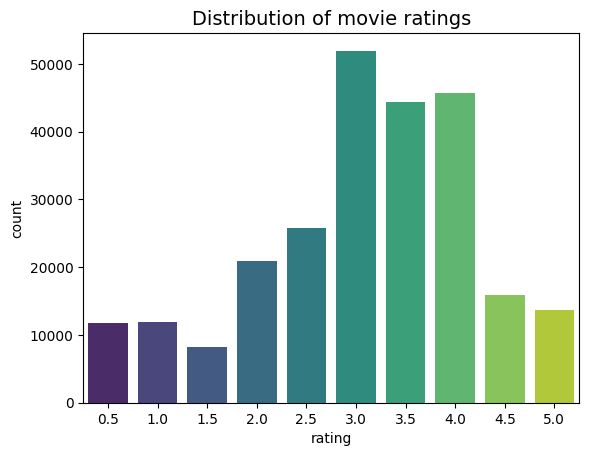

In [9]:
sns.countplot(x="rating", data=ratings, palette="viridis")
plt.title("Distribution of movie ratings", fontsize=14)
plt.show()

In [10]:
movie_ratings = ratings.merge(movies, on='movieId')
movie_ratings['title'].value_counts()[0:10]

,count
title,
Seven (a.k.a. Se7en) (1995),99
Pulp Fiction (1994),98
"Matrix, The (1999)",98
"Shawshank Redemption, The (1994)",97
"Sixth Sense, The (1999)",97
"Usual Suspects, The (1995)",96
Terminator 2: Judgment Day (1991),96
Forrest Gump (1994),96
"Silence of the Lambs, The (1991)",96


In [11]:
print(f"Mean global rating: {round(ratings['rating'].mean(),2)}.")

mean_ratings = ratings.groupby('userId')['rating'].mean()
print(f"Mean rating per user: {round(mean_ratings.mean(),2)}.")

Mean global rating: 3.08.
Mean rating per user: 3.14.


In [12]:
mean_ratings = ratings.groupby('movieId')[['rating']].mean()
lowest_rated = mean_ratings['rating'].idxmin()
print(movies[movies['movieId']==lowest_rated])
highest_rated = mean_ratings['rating'].idxmax()
print(movies[movies['movieId'] == highest_rated])

     movieId              title  genres
306      310  Rent-a-Kid (1995)  Comedy
    movieId            title genres
66       67  Two Bits (1995)  Drama


In [13]:
highest_rated = mean_ratings['rating'].idxmax()
movies[movies['movieId'] == highest_rated]

,movieId,title,genres
66,67,Two Bits (1995),Drama


In [14]:
movie_stats = ratings.groupby('movieId')[['rating']].agg(['count', 'mean'])
movie_stats.columns = movie_stats.columns.droplevel()

In [15]:
C = movie_stats['count'].mean()
m = movie_stats['mean'].mean()

def bayesian_avg(ratings):
    bayesian_avg = (C*m+ratings.sum())/(C+ratings.count())
    return bayesian_avg

bayesian_avg_ratings = ratings.groupby('movieId')['rating'].agg(bayesian_avg).reset_index()
bayesian_avg_ratings.columns = ['movieId', 'bayesian_avg']

movie_stats = movie_stats.merge(bayesian_avg_ratings, on='movieId')
movie_stats.describe()

,movieId,count,mean,bayesian_avg
count,32420.000000,32420.000000,32420.000000,32420.000000
mean,109650.359655,7.718322,2.825105,2.863064
std,81608.744388,13.416120,0.964497,0.272595
min,1.000000,1.000000,0.500000,1.526249
25%,26868.750000,1.000000,2.333333,2.706750
50%,113770.000000,2.000000,3.000000,2.845165
75%,173357.000000,7.000000,3.500000,2.985248
max,292467.000000,99.000000,5.000000,4.271364


In [16]:
movie_ratings['movieId'].nunique()
M = movie_ratings['userId'].nunique()
user_mapper = dict(zip(np.unique(movie_ratings["userId"]), list(range(M))))

In [17]:
from scipy.sparse import csr_matrix

def create_sparse(df):
    """
    Generates a sparse matrix from ratings dataframe.

    Args:
        df: pandas dataframe containing 3 columns (userId, movieId, rating)

    Returns:
        X: sparse matrix
        user_mapper: dict that maps user id's to user indices
        user_inv_mapper: dict that maps user indices to user id's
        movie_mapper: dict that maps movie id's to movie indices
        movie_inv_mapper: dict that maps movie indices to movie id's
    """
    M = df['userId'].nunique()
    N = df['movieId'].nunique()

    user_mapper = dict(zip(np.unique(df["userId"]), list(range(M))))
    movie_mapper = dict(zip(np.unique(df["movieId"]), list(range(N))))

    user_inv_mapper = dict(zip(list(range(M)), np.unique(df["userId"])))
    movie_inv_mapper = dict(zip(list(range(N)), np.unique(df["movieId"])))

    user_index = [user_mapper[i] for i in df['userId']]
    item_index = [movie_mapper[i] for i in df['movieId']]

    X = csr_matrix((df["rating"], (user_index, item_index)), shape=(M,N))

    return X, user_mapper, movie_mapper, user_inv_mapper, movie_inv_mapper

X, user_mapper, movie_mapper, user_inv_mapper, movie_inv_mapper = create_sparse(ratings)

In [18]:
sparsity = X.count_nonzero()/(X.shape[0]*X.shape[1])

print(f"Matrix sparsity: {round(sparsity*100,2)}%")

Matrix sparsity: 7.72%


Wykorzystaj algorytm najblizszych sąsiadów, żeby podać 10 filmów po obejrzeniu *Toy* *Story*

In [19]:
from sklearn.neighbors import NearestNeighbors

def find_similar_movies(movie_id, X, k, metric='cosine', show_distance=False):
    """
    Finds k-nearest neighbours for a given movie id.

    Args:
        movie_id: id of the movie of interest
        X: user-item utility matrix
        k: number of similar movies to retrieve
        metric: distance metric for kNN calculations

    Returns:
        list of k similar movie ID's
    """
    neighbour_ids = []

    # Transpose the user-item matrix X to an item-user matrix X_movies
    # Now, each row in X_movies corresponds to a movie, and columns to users
    X_movies = X.T

    # Get the internal index for the movie_id from movie_mapper
    # This index is a row index in X_movies
    target_movie_idx = movie_mapper[movie_id]

    # Extract the vector for the target movie from X_movies
    target_movie_vec = X_movies[target_movie_idx]

    # Initialize kNN model. k+1 because the movie itself will be the closest neighbor
    kNN = NearestNeighbors(n_neighbors=k+1, algorithm="brute", metric=metric)
    kNN.fit(X_movies) # Fit the model on the movie-user matrix

    # Reshape movie_vec if it's a 1D array to a 2D array for kneighbors
    if isinstance(target_movie_vec, (np.ndarray)):
        target_movie_vec = target_movie_vec.reshape(1,-1)

    # Find k+1 nearest neighbors (distances and indices)
    if show_distance:
        distances, indices = kNN.kneighbors(target_movie_vec, return_distance=True)
    else:
        indices = kNN.kneighbors(target_movie_vec, return_distance=False)

    # Iterate through the neighbors, skipping the first one (the movie itself)
    for i in range(1, len(indices[0])):
        # 'idx' is the internal index of the similar movie in the sparse matrix
        idx = indices[0][i]
        # Map this internal index back to the original movieId using movie_inv_mapper
        neighbour_ids.append(movie_inv_mapper[idx])

    return neighbour_ids

In [20]:
movie_titles = dict(zip(movies['movieId'], movies['title']))
movie_id = 1

similar_ids = find_similar_movies(movie_id, X, k=10)
movie_title = movie_titles[movie_id]

print(f"Because you watched {movie_title}")
for i in similar_ids:
    print(movie_titles[i])

Because you watched Toy Story (1995)
Incredibles, The (2004)
Toy Story 2 (1999)
Finding Nemo (2003)
Raiders of the Lost Ark (Indiana Jones and the Raiders of the Lost Ark) (1981)
Star Wars: Episode V - The Empire Strikes Back (1980)
Star Wars: Episode IV - A New Hope (1977)
Jurassic Park (1993)
Star Wars: Episode VI - Return of the Jedi (1983)
Sixth Sense, The (1999)
Monsters, Inc. (2001)


Wykorzystaj algorytm SVD, żeby podać 10 filmów po obejrzeniu *Toy* *Story*

cz1: klasyczne SVD (biblioteka **NumPy**)

In [26]:
import numpy as np

def svd_reconstruct(R, k=2):
    """
    Aproksymacja macierzy przez klasyczne SVD (biblioteka NumPy)
    """
    U, S, Vt = np.linalg.svd(R, full_matrices=False)

    S_k = np.diag(S[:k])

    R_approx = np.dot(U[:, :k], np.dot(S_k, Vt[:k, :]))

    return R_approx

cz2: TruncatedSVD (scikit-learn)


In [27]:
import numpy as np
from sklearn.decomposition import TruncatedSVD

def truncated_svd_reconstruct(R, k=2):
    """
    Aproksymacja macierzy przez TruncatedSVD (sklearn)
    """
    svd = TruncatedSVD(n_components=k, random_state=42)

    R_approx = svd.inverse_transform(svd.fit_transform(R))

    return R_approx

wywołaj obie funkcje i stworz rekomentacje dla uzytkownika nr 10

In [28]:
user_idx = 10
user_id = user_inv_mapper[user_idx]

R_svd = svd_reconstruct(X.toarray(), k=20)
R_trunc = truncated_svd_reconstruct(X, k=20)

def get_recommendations(R_original, R_pred, user_idx):
    recs = []
    for item_idx in range(R_original.shape[1]):
        if R_original[user_idx, item_idx] == 0:
            movie_id = movie_inv_mapper[item_idx]
            predicted_rating = R_pred[user_idx, item_idx]
            recs.append((movie_id, predicted_rating))

    return sorted(recs, key=lambda x: x[1], reverse=True)

recs_svd = get_recommendations(X.toarray(), R_svd, user_idx)
recs_trunc = get_recommendations(X.toarray(), R_trunc, user_idx)

print(f"Generowanie rekomendacji dla użytkownika ID: {user_id} (Indeks: {user_idx})\n")

print("Top 10 SVD:")
for movie_id, score in recs_svd[:10]:
    print(f"{movie_titles[movie_id]} (Przewidywana ocena: {score:.3f})")

print("-------------------------------")

print("Top 10 Truncated SVD:")
for movie_id, score in recs_trunc[:10]:
    print(f"{movie_titles[movie_id]} (Przewidywana ocena: {score:.3f})")

Generowanie rekomendacji dla użytkownika ID: 1739 (Indeks: 10)

Top 10 SVD:
Forrest Gump (1994) (Przewidywana ocena: 3.269)
Fight Club (1999) (Przewidywana ocena: 3.152)
Green Mile, The (1999) (Przewidywana ocena: 3.111)
Equilibrium (2002) (Przewidywana ocena: 2.940)
Panic Room (2002) (Przewidywana ocena: 2.784)
First Blood (Rambo: First Blood) (1982) (Przewidywana ocena: 2.707)
Titanic (1997) (Przewidywana ocena: 2.672)
RoboCop (1987) (Przewidywana ocena: 2.670)
Equalizer, The (2014) (Przewidywana ocena: 2.667)
Others, The (2001) (Przewidywana ocena: 2.640)
-------------------------------
Top 10 Truncated SVD:
Forrest Gump (1994) (Przewidywana ocena: 3.269)
Fight Club (1999) (Przewidywana ocena: 3.146)
Green Mile, The (1999) (Przewidywana ocena: 3.048)
Equilibrium (2002) (Przewidywana ocena: 2.861)
Titanic (1997) (Przewidywana ocena: 2.769)
Equalizer, The (2014) (Przewidywana ocena: 2.749)
Panic Room (2002) (Przewidywana ocena: 2.724)
First Blood (Rambo: First Blood) (1982) (Przewidyw

KLUCZOWA różnica (najważniejsze)
SVD:

* działa na pełnej macierzy
* traktuje brak ocen jako 0 → to jest BŁĄD modelowy

TruncatedSVD:

* działa na macierzy sparse
* ale nadal NIE rozróżnia: brak oceny vs słaba ocena



Ocena modeli - policz RSME na macierzach tylko na niezerowych elementach